# Data Evaluation: Solvability (User Study Task 1)

## 0. Setup

In [ ]:
import pandas as pd
import matplotlib as mpl
%matplotlib inline

data_df = pd.read_csv('../ma-eval/protocol-data.csv')
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,p_answered_miro,p_answered_pixie,p_answered_correct_miro,p_answered_correct_pixie
0,2,PA40344,2026-06-29,AP,4,4,NaN,2,2,NaN,6,6,NaN,NaN
1,5,MA7125,2026-06-30,AM,4,1,3.0,2,2,0.0,4,3,NaN,NaN
2,21,MA26593,2026-07-07,AM,1,1,0.0,0,0,0.0,3,4,NaN,NaN
3,20,PB3394,2026-07-06,BP,2,2,0.0,0,0,0.0,6,6,NaN,NaN
4,14,PA4076,2026-07-02,AP,1,1,0.0,5,4,1.0,6,4,NaN,NaN
5,16,PB46220,2026-07-02,BP,5,4,1.0,1,1,0.0,5,3,NaN,NaN
6,6,PA45003,2026-06-30,AP,2,2,0.0,1,1,0.0,3,4,NaN,NaN
7,4,PB54700,2026-06-30,BP,3,3,0.0,1,1,0.0,6,3,NaN,NaN
8,7,MB24145,2026-06-30,BM,3,3,0.0,2,1,1.0,1,4,NaN,NaN
9,15,MB10509,2026-07-02,BM,2,2,0.0,1,1,0.0,3,5,NaN,NaN


## 1. Counts of Identified Issues

In [42]:
total_counts_solvability = [
    's_iss_miro',
    's_iss_pixie',
]

#### Distribution of Total Number of Identified Issues Across Participants By Tool

includes incorrect answers

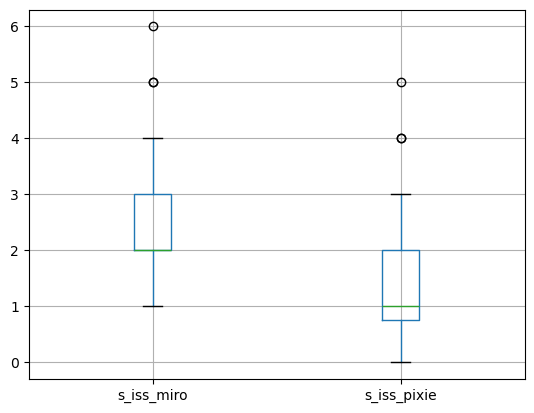

In [43]:
total_solvability_boxplot = data_df.boxplot(column=total_counts_solvability)

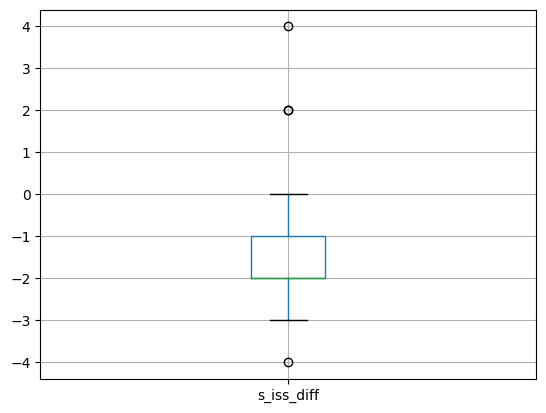

In [44]:
data_df['s_iss_diff'] = data_df['s_iss_pixie'] - data_df['s_iss_miro']
solvability_diff = data_df.boxplot(column=['s_iss_diff'])

#### Distribution of Total Number of Identified Issues Across Participants By Tool And Group

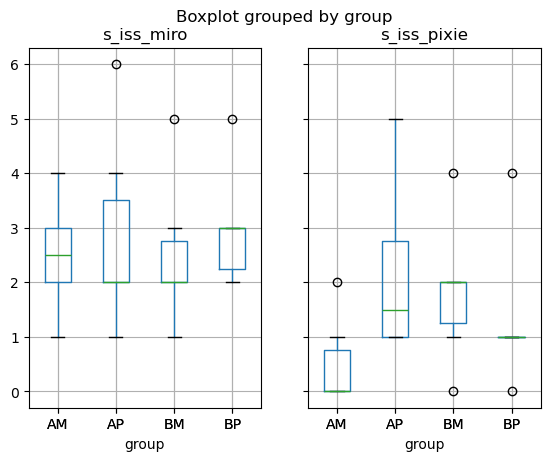

In [63]:
total_solvability_by_group_boxplot = data_df.boxplot(column=total_counts_solvability, by='group')

### Precision

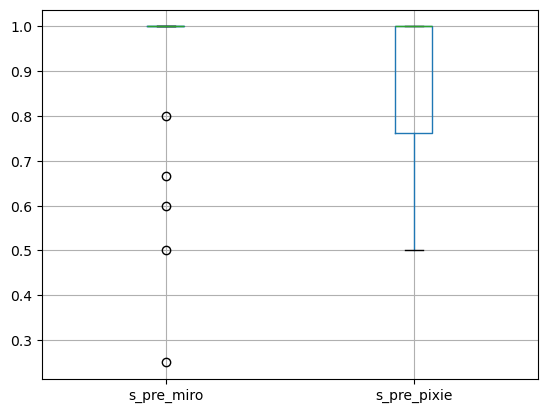

In [45]:
TOTAL_ISSUES = 6

data_df['s_pre_miro'] = data_df['s_tp_miro'] / data_df['s_iss_miro']
data_df['s_pre_pixie'] = data_df['s_tp_pixie'] / data_df['s_iss_pixie']

solvability_precision_boxplot = data_df.boxplot(column=['s_pre_miro', 's_pre_pixie'])

In [46]:
# NOTE: missing values for precision when 0 issues identified
data_df[['s_pre_miro', 's_pre_pixie']].describe()

,s_pre_miro,s_pre_pixie
count,24.000000,18.000000
mean,0.909028,0.873148
std,0.200541,0.199111
min,0.250000,0.500000
25%,1.000000,0.762500
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


### Recall

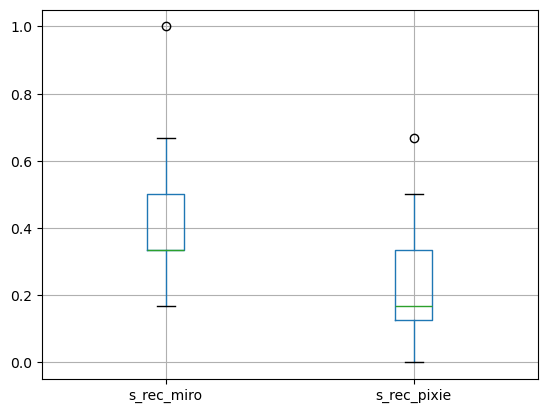

In [47]:
data_df['s_rec_miro'] = data_df['s_tp_miro'] / TOTAL_ISSUES
data_df['s_rec_pixie'] = data_df['s_tp_pixie'] / TOTAL_ISSUES

solvability_recall_boxplot = data_df.boxplot(column=['s_rec_miro', 's_rec_pixie'])

In [48]:
data_df[['s_rec_miro', 's_rec_pixie']].describe()

,s_rec_miro,s_rec_pixie
count,24.000000,24.000000
mean,0.395833,0.194444
std,0.195434,0.167870
min,0.166667,0.000000
25%,0.333333,0.125000
50%,0.333333,0.166667
75%,0.500000,0.333333
max,1.000000,0.666667


### F1

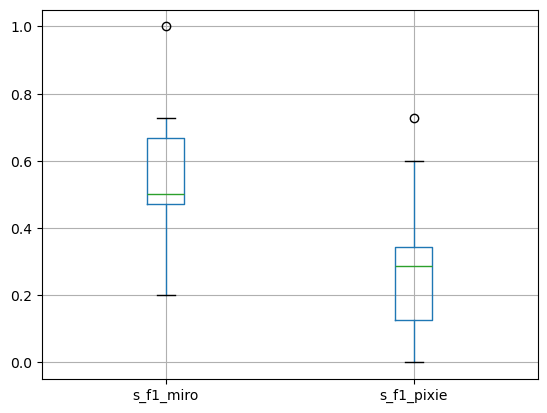

In [49]:
data_df['s_f1_miro'] = 2 * data_df['s_tp_miro'] / (2 * data_df['s_tp_miro'] + data_df['s_fp_miro'] + (TOTAL_ISSUES - data_df['s_tp_miro']))
data_df['s_f1_pixie'] = 2 * data_df['s_tp_pixie'] / (2 * data_df['s_tp_pixie'] + data_df['s_fp_pixie'] + (TOTAL_ISSUES - data_df['s_tp_pixie']))
solvability_f1_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'])

In [59]:
data_df[['s_f1_miro', 's_f1_pixie']].describe()

# TODO: investigate missing value

,s_f1_miro,s_f1_pixie
count,23.000000,23.000000
mean,0.513574,0.269026
std,0.182115,0.201027
min,0.200000,0.000000
25%,0.472222,0.125000
50%,0.500000,0.285714
75%,0.666667,0.342857
max,1.000000,0.727273


#### F1 Difference Per Participant

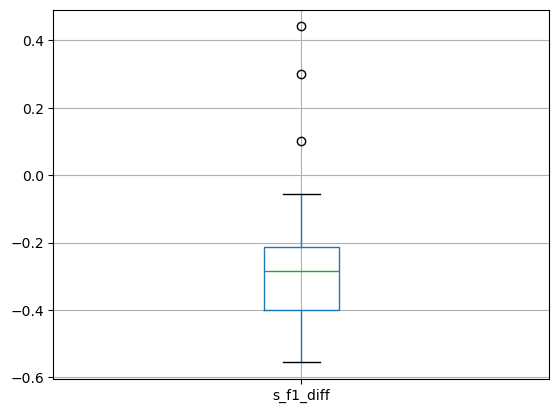

In [60]:
data_df['s_f1_diff'] = data_df['s_f1_pixie'] - data_df['s_f1_miro']
solvability_f1_diff = data_df.boxplot(column=['s_f1_diff'])

In [61]:
data_df['s_f1_diff'].describe()

count    23.000000
mean     -0.244548
std       0.248612
min      -0.555556
25%      -0.398810
50%      -0.285714
75%      -0.214286
max       0.441558
Name: s_f1_diff, dtype: float64

#### F1 Stratified By Group

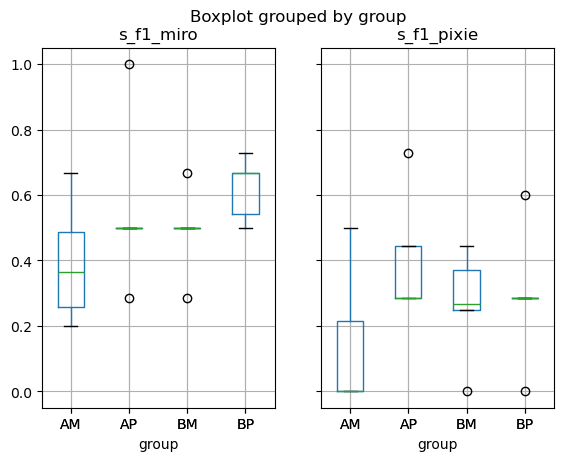

In [62]:
solvability_f1_by_group_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='group')

## 2. Issues In Time

In [52]:
timeseries_data_df = pd.read_csv('../eval-toolchain/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"no, B has more enemies than C",232
822,PA38184,AP,pacing_miro,LA_2,14:46:07,Q5A,21-2 to 21-3,290


In [53]:
issues_data_df = timeseries_data_df[timeseries_data_df['tag'] == 'ISS']
issues_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
31,MA7125,AM,solvability_pixie,LA_4,11:32:16,ISS,? missing key between 31 and Boss,78
32,MA7125,AM,solvability_pixie,LA_4,11:33:16,ISS,TP 12 not reachable,138
35,MA7125,AM,solvability_pixie,LA_4,11:36:42,ISS,TP one-directional path 12-11,344
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path (evl: incl...,231
40,MA7125,AM,solvability_miro,LA_3,11:27:49,ISS,TP one-directional path 12-15,260
...,...,...,...,...,...,...,...,...
772,MB67500,BM,solvability_miro,LA_4,15:25:46,ISS,TP can't get to area 28 bc one-directional edge,205
797,PA38184,AP,solvability_pixie,LA_3,14:26:16,ISS,TP need 6 bombs for 22-23 but only get one on ...,270
802,PA38184,AP,solvability_miro,LA_4,14:29:18,ISS,TP can't unlock edge 6 - 12,92
804,PA38184,AP,solvability_miro,LA_4,14:30:18,ISS,? can't unlock 12-11 (ability unreachable),152


In [54]:
first_issues_df = issues_data_df.loc[issues_data_df.groupby(['p_id', 'task']).timedelta.idxmin()]
first_issues_df

,p_id,group,task,map,timestamp,tag,note,timedelta
629,MA12534,AM,solvability_miro,LA_3,11:21:21,ISS,"TP hard lock 6, pretty confident",159
69,MA26593,AM,solvability_miro,LA_3,11:23:57,ISS,TP softlock in 4 if ability check not passed,99
452,MA34230,AM,solvability_miro,LA_3,17:26:49,ISS,TP if bomb used on 13 - 14: softlock in 14,130
446,MA34230,AM,solvability_pixie,LA_4,17:36:46,ISS,TP 6-12 not unlockable,270
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path (evl: incl...,231
31,MA7125,AM,solvability_pixie,LA_4,11:32:16,ISS,? missing key between 31 and Boss,78
373,MA95137,AM,solvability_miro,LA_3,15:26:14,ISS,TP hardlocked in 6,39
694,MA95935,AM,solvability_miro,LA_3,16:26:50,ISS,TP not enough bombs 22-23,156
313,MB10509,BM,solvability_miro,LA_4,13:27:50,ISS,"? can get to 31, but no further",127
304,MB10509,BM,solvability_pixie,LA_3,13:34:03,ISS,TP hardlock in 6,40


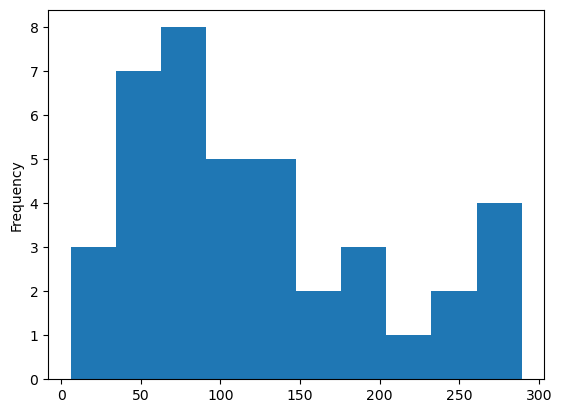

In [55]:

time_to_first_issue_hist = first_issues_df['timedelta'].plot.hist()
# time_to_first_issue_hist = first_issues_df.timedelta.plot.hist(groupby='task')
# time_to_first_issue_hist = first_issues_df.plot.hist('timadelta', by='task')

##### Distribution of First Issue Found Events Across Participants By Task

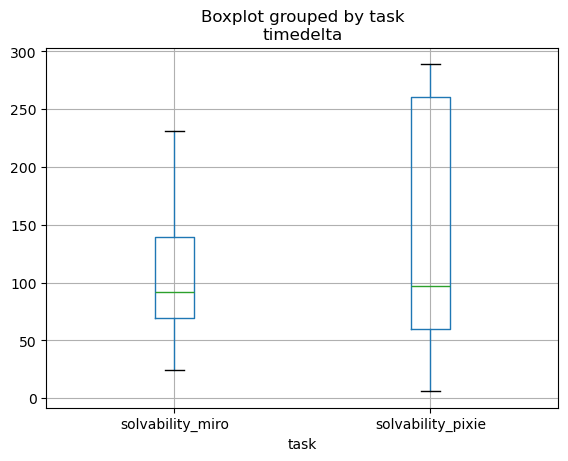

In [56]:
time_to_first_issue_box = first_issues_df.boxplot(by='task', column='timedelta')

##### Time To First Issue By Tool And Map

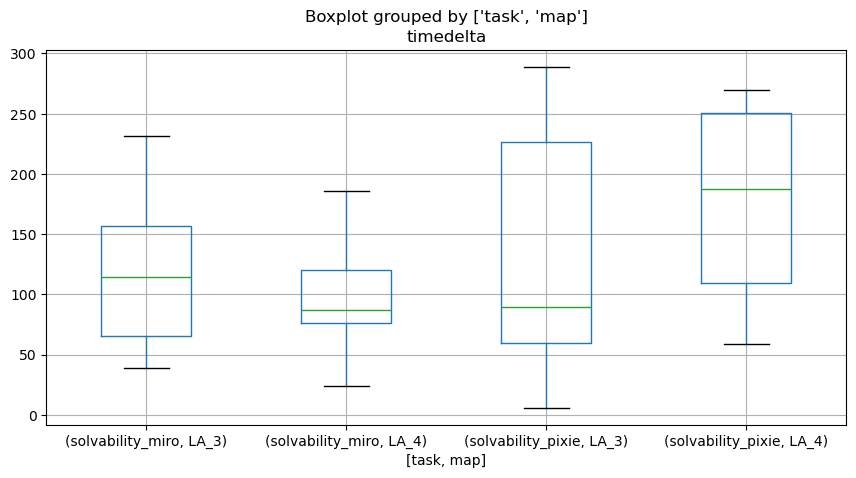

In [57]:
time_to_first_issue_box_task = first_issues_df.boxplot(by=['task', 'map'], column='timedelta', figsize=(10, 5))

##### Distribution of Issue Found Events Across Time

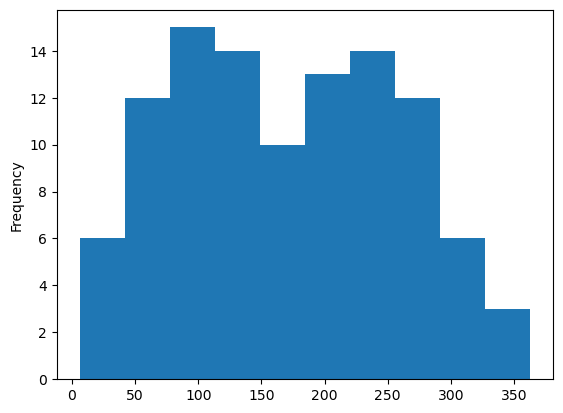

In [58]:
ax2 = issues_data_df['timedelta'].plot.hist()